# CONTENT FLOW

1. Imports

2. Load Dataset

3. Quality Control

4. Preprocessing

5. Baseline Clustering
   + PCA
   + UMAP
   + Marker genes
   + Evaluation metrics

6. Parameter Optimization
   + Grid search
   + Results table
   + Best parameters

7. Agentic AI Optimization
   + LangGraph workflow
   + Suggested parameters
   + Evaluation

8. Comparison
   + Baseline vs Grid Search vs Agentic AI
   + Metrics table
   + Final UMAPs
   + Marker genes

In [1]:
%load_ext autoreload
%autoreload 2

In [1]:
from src import data_load as dl
from src import preprocessing_pipeline as prp
from src import clustering as cl
from src import evaluation as ev
from src import optimization as opt
from src import visualisation as viz
from src import marker as mk

import scanpy as sc
import pandas as pd

## Data Load

In [2]:
pbmc_data = dl.load_pbmc3k()

## Preprocessing (QC, Normalisation/Scaling, PCA)

In [3]:
pbmc_data = prp.run_preprocessing_pipeline(pbmc_data)

Running QC...
Running normalization...
Running PCA...
Finished preprocessing.


In [4]:
pbmc_data.var["highly_variable"].sum()

np.int64(2000)

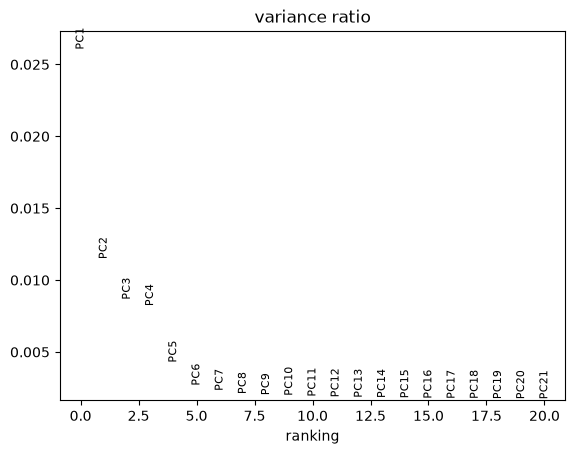

In [5]:
sc.pl.pca_variance_ratio(pbmc_data, n_pcs=20)

# Baseline Clustering

In [6]:
pbmc_data = cl.run_clustering(pbmc_data)

In [7]:
print(pbmc_data.obs.columns)

Index(['n_genes', 'n_genes_by_counts', 'log1p_n_genes_by_counts',
       'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes',
       'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes',
       'pct_counts_in_top_500_genes', 'total_counts_mt',
       'log1p_total_counts_mt', 'pct_counts_mt', 'leiden'],
      dtype='object')


In [9]:
ev.get_cluster_summary(pbmc_data)

{'0': 574,
 '1': 552,
 '2': 347,
 '3': 299,
 '4': 164,
 '5': 465,
 '6': 168,
 '7': 23,
 '8': 32,
 '9': 14}

In [10]:
# Current Parameter Used
pbmc_data.uns["clustering_params"]

{'n_neighbors': 15, 'resolution': 1.0, 'n_pcs': 20, 'random_state': 42}

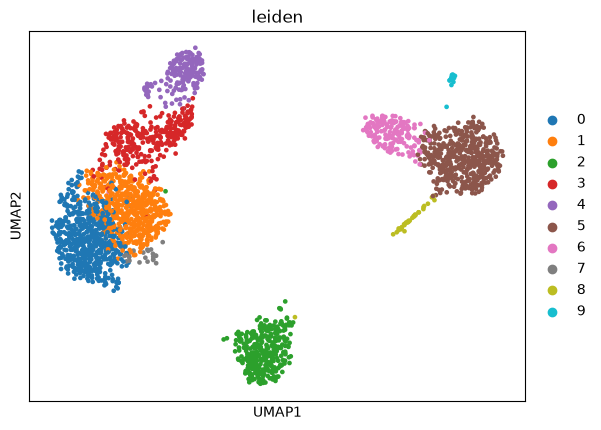

In [11]:
viz.plot_umap(pbmc_data, color="leiden")

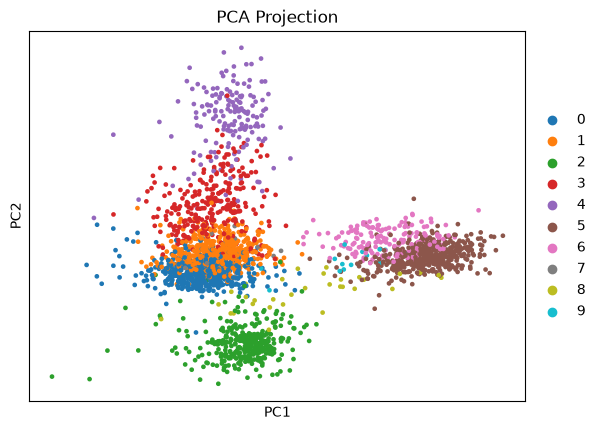

In [12]:
# PCA colored by clusters
viz.plot_pca(pbmc_data, color="leiden", title="PCA Projection",show=True)

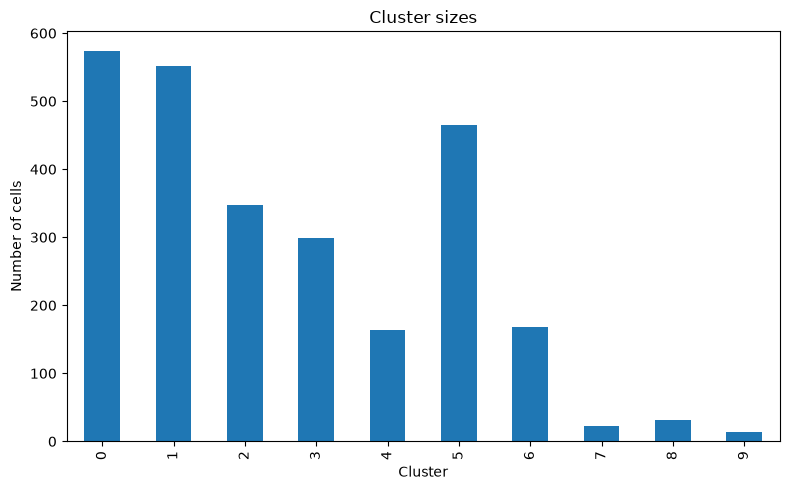

In [13]:
# Plot cluster sizes
viz.plot_cluster_sizes(pbmc_data)

## Evaluation with Internal Metrics silhoutte score and Davies_bouldin score

In [14]:
baseline_metrics = ev.evaluate_clustering(pbmc_data)
baseline_metrics

{'n_neighbors': 15,
 'resolution': 1.0,
 'n_pcs': 20,
 'random_state': 42,
 'n_clusters': 10,
 'cluster_sizes': {'0': 574,
  '1': 552,
  '2': 347,
  '3': 299,
  '4': 164,
  '5': 465,
  '6': 168,
  '7': 23,
  '8': 32,
  '9': 14},
 'silhouette_score': 0.07478884607553482,
 'davies_bouldin_score': 2.666380841974742}

# Clustering Parameter Optimisation
By performing a grid search over different clustering parameters.

In [ ]:
# RELOAD DATA
pbmc_data = dl.load_pbmc3k()

### Markers Genes

In [ ]:
pbmc_data = mk.find_marker_genes(pbmc_data)

In [ ]:
# Visualize marker genes
# mk.plot_marker_genes(pbmc_data)

In [ ]:
# mk.plot_marker_heatmap(pbmc_data)

In [ ]:
# mk.plot_marker_dotplot(pbmc_data)